========================================================================================================================
## Credit Card Fraud Detection – Exploratory Data Analysis
========================================================================================================================

-------------------------------------------------------------------------------------------------
### Business Problem Understanding
-------------------------------------------------------------------------------------------------

Credit card fraud is a major challenge for financial institutions.
Fraudulent transactions cause significant financial losses and reduce customer trust.

Banks and payment companies need automated systems that can quickly identify suspicious
transactions and prevent fraudulent payments.

However, fraud detection is a difficult problem because:

- Fraud transactions are extremely rare compared to normal transactions
- Fraud patterns constantly change
- Fraudsters try to mimic legitimate transaction behavior

The goal of this project is to analyze transaction data and identify patterns that
distinguish fraudulent transactions from normal ones.

The insights obtained from exploratory data analysis will help design effective
machine learning models for fraud detection.

-------------------------------------------------------------------------------------------------
### Project Objective
-------------------------------------------------------------------------------------------------

The objective of this analysis is to explore the credit card transaction dataset
and understand the characteristics of fraudulent transactions.

This notebook focuses on:

- Understanding the structure of the dataset
- Identifying class imbalance
- Detecting outliers and unusual patterns
- Analyzing feature distributions
- Investigating correlations between features
- Identifying variables strongly associated with fraud

These insights will guide feature engineering and machine learning model development
for the fraud detection system.

-------------------------------------------------------------------------------------------------
### Dataset Description
-------------------------------------------------------------------------------------------------

The dataset contains credit card transactions made by European cardholders.

It includes transactions that occurred over a two-day period.

The dataset contains:

- 284,807 transactions
- 31 features

Feature Details:

Time – Time elapsed between this transaction and the first transaction in the dataset

Amount – Transaction amount

V1–V28 – Anonymized numerical features generated using PCA transformation

Class – Target variable

0 → Normal Transaction  
1 → Fraudulent Transaction

Due to confidentiality issues, the original features are transformed using PCA,
which is why most variables are labeled V1 to V28.

-------------------------------------------------------------------------------------------------
### Challenges in Fraud Detection
-------------------------------------------------------------------------------------------------

Fraud detection datasets present several challenges:

1. Extreme class imbalance
   Fraud transactions represent less than 1% of total transactions.

2. Highly anonymized features
   Many variables are PCA components, which makes interpretation difficult.

3. Dynamic fraud patterns
   Fraud behavior changes frequently over time.

These challenges make it necessary to perform careful exploratory data analysis
before building machine learning models.

-------------------------------------------------------------------------------------------------
### Why Exploratory Data Analysis
-------------------------------------------------------------------------------------------------

Exploratory Data Analysis (EDA) is performed to understand the structure
and characteristics of the dataset.

EDA helps us:

- Identify class imbalance
- Detect outliers and anomalies
- Understand feature distributions
- Analyze correlations between variables
- Discover patterns related to fraudulent transactions

These insights help improve feature engineering,
model selection, and fraud detection performance.

-------------------------------------------------------------------------------------------------
### Notebook Workflow
-------------------------------------------------------------------------------------------------

This notebook follows a structured workflow:

1. Data Loading and Dataset Inspection
2. Data Quality Checks
3. Missing Value Analysis
4. Duplicate Detection
5. Statistical Feature Analysis
6. Outlier Detection
7. Skewness and Feature Transformation
8. Fraud vs Non-Fraud Analysis
9. Correlation Analysis
10. Feature Engineering

The goal is to extract meaningful insights that can
improve the performance of fraud detection models.

========================================================================================================================

-------------------------------------------------------------------
### Step 1 – Data Loading and Initial Dataset Inspection
-------------------------------------------------------------------

The first step in any data science project is loading the dataset
and inspecting its structure.

We load the credit card fraud dataset using pandas and examine
the first few rows to understand the available features.

This helps verify that the dataset is correctly loaded and provides
an initial view of the transaction data.

In [105]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from feature_engine.outliers import Winsorizer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("D:\\Data Science Datasets\\Credit Card Fraud Detection.csv")
df.head().T

,0,1,2,3,4
Time,0.000000,0.000000,1.000000,1.000000,2.000000
V1,-1.359807,1.191857,-1.358354,-0.966272,-1.158233
V2,-0.072781,0.266151,-1.340163,-0.185226,0.877737
V3,2.536347,0.166480,1.773209,1.792993,1.548718
V4,1.378155,0.448154,0.379780,-0.863291,0.403034
V5,-0.338321,0.060018,-0.503198,-0.010309,-0.407193
V6,0.462388,-0.082361,1.800499,1.247203,0.095921
V7,0.239599,-0.078803,0.791461,0.237609,0.592941
V8,0.098698,0.085102,0.247676,0.377436,-0.270533
V9,0.363787,-0.255425,-1.514654,-1.387024,0.817739


---------------------------------------------------------
### Step 2 – Dataset Structure and Data Types
---------------------------------------------------------

We examine the dataset structure using df.info() to understand:

- Number of rows and columns
- Data types of each feature
- Presence of missing values

Understanding the dataset structure helps ensure that all variables
are correctly interpreted before performing further analysis.

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

----------------------------------------------
### Step 3 – Dataset Size Inspection
----------------------------------------------

We check the dataset shape to understand the scale of the data.

Large datasets are common in fraud detection because financial
systems generate millions of transactions daily.

Knowing the dataset size helps plan computational and modeling strategies.

In [107]:
df.shape

(284807, 31)

----------------------------------------------
### Step 4 – Missing Values Analysis
----------------------------------------------

Missing values can affect model performance and statistical analysis.

We check whether any feature contains null values.

In this dataset, all features are complete, which simplifies
the preprocessing process.

In [108]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

------------
### Step 5 – Duplicate Transaction Detection
-------------

Duplicate transactions may introduce bias into the dataset
and affect model training.

We identify and remove duplicate rows to ensure the dataset
contains only unique transactions.

Removing duplicates improves data quality and prevents
data leakage during model training.

In [109]:
df.duplicated().sum()

1081

In [110]:
# REMOVE DUPLICATES
df.drop_duplicates(inplace= True, ignore_index= True)

In [111]:
print("Duplicates after:", df.duplicated().sum())

Duplicates after: 0


-----------------------------
### Step 6 – Transaction Amount Statistical Summary
----------------

Transaction amount is a critical variable in fraud detection.

We analyze its statistical distribution using descriptive statistics
to understand the range, central tendency, and extreme values.

This helps identify unusually large transactions that may indicate fraud.

In [112]:
# BASIC OUTLIER CHECK (Amount)
print(df["Amount"].describe())

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


------------
### Step 7 – Feature Type Segregation
---------------
Features are categorized into continuous and discrete variables.

Feature type identification is important because different
analysis techniques are applied depending on the feature type.

In this dataset, most variables are continuous because
they are generated through PCA transformation.

In [113]:
target_col = "Class"

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols.remove(target_col)

continuous_cols = []
discrete_cols = []

for col in numeric_cols:
    if df[col].nunique() > 15:
        continuous_cols.append(col)
    else:
        discrete_cols.append(col)

print("Continuous Features:", continuous_cols)
print("Discrete Features:", discrete_cols)

Continuous Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Discrete Features: []


----------------
### Step 8 – Outlier Detection Using IQR Method
-------------------
Outliers can significantly influence machine learning models.

We apply the Interquartile Range (IQR) method to identify
transactions that fall outside the normal range of feature values.

The analysis reveals which variables contain the highest
percentage of extreme values.

In [114]:
def detect_outliers_iqr(data, columns):
    summary = []

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower) | (data[col] > upper)]
        summary.append([col, len(outliers), round(len(outliers)/len(data)*100,2)])

    return pd.DataFrame(summary, columns=["Feature","Outlier_Count","Outlier_%"])

# RUN THE FUNCTION
outlier_report = detect_outliers_iqr(df, continuous_cols)

print(outlier_report.sort_values("Outlier_%", ascending=False).head(10))

   Feature  Outlier_Count  Outlier_%
27     V27          38799      13.67
29  Amount          31685      11.17
28     V28          30094      10.61
20     V20          27553       9.71
8       V8          23904       8.43
6       V6          22886       8.07
23     V23          18467       6.51
12     V12          15282       5.39
21     V21          14401       5.08
14     V14          14060       4.96


------------------
### Step 9 – Fraud Ratio within Outlier Transactions
---------------

This step evaluates whether outlier values are associated
with a higher probability of fraud.

By calculating the fraud ratio among outlier observations,
we can determine whether extreme values are meaningful signals
for fraud detection.

In [115]:
def fraud_ratio_in_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return outliers["Class"].mean()

for col in continuous_cols[:5]:
    print(col, fraud_ratio_in_outliers(df, col))

Time nan
V1 0.02274035693724813
V2 0.01717699775952203
V3 0.08862673926194797
V4 0.02704164413196322


-----------------
### Step 10 – Skewness Analysis of Continuous Features
--------------------

Skewed features can negatively impact machine learning models,
especially distance-based algorithms.

We compute skewness values to identify features with highly
asymmetric distributions.

Highly skewed variables may require transformation
to stabilize their distribution.

In [116]:
skewness = df[continuous_cols].skew().sort_values(ascending=False)
print(skewness.head(10))

high_skew = skewness[abs(skewness) > 1].index.tolist()
print("Highly Skewed:", high_skew)

Amount    16.978803
V28       11.555115
V7         2.890271
V21        2.820033
V6         1.829880
V10        1.252967
V4         0.671504
V26        0.580292
V9         0.537663
V11        0.344074
dtype: float64
Highly Skewed: ['Amount', 'V28', 'V7', 'V21', 'V6', 'V10', 'V16', 'V14', 'V20', 'V3', 'V12', 'V5', 'V1', 'V17', 'V2', 'V23', 'V8']


------------------
### Step 11 – Skewness Reduction Using Power Transformation
--------------------

To reduce skewness, we apply the Yeo-Johnson power transformation
to the transaction amount feature.

This transformation helps normalize the distribution and improves
model performance by stabilizing variance across values.

In [117]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df["Amount"] = pt.fit_transform(df[["Amount"]])

-----------------
### Step 12 – Statistical Significance Testing (Fraud vs Non-Fraud)
----------------

Statistical hypothesis testing is used to determine whether
feature distributions differ significantly between fraudulent
and non-fraudulent transactions.

We use the Mann-Whitney U test to compare distributions
without assuming normality.

Features with significant p-values may provide useful signals
for fraud detection models.

In [118]:
# Optional statistical validation (documentation only)

from scipy.stats import mannwhitneyu

significant_features = []

for col in continuous_cols:
    fraud = df[df[target_col]==1][col]
    non_fraud = df[df[target_col]==0][col]

    u_stat, p_val = mannwhitneyu(fraud, non_fraud)

    if p_val < 0.05:
        significant_features.append(col)
        
print("Statistically Significant Features:", significant_features[:10])

Statistically Significant Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']


------------------
### Step 13 – Effect Size Analysis (Cohen’s d)
---------------

While statistical significance shows whether a difference exists,
effect size measures the magnitude of that difference.

We compute Cohen’s d to identify features where fraud and
non-fraud transactions differ meaningfully.

Features with larger effect sizes are potentially more useful
for machine learning models.

In [119]:
def cohens_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2)/2)

important_features = []

for col in continuous_cols:
    fraud = df[df["Class"]==1][col]
    non_fraud = df[df["Class"]==0][col]
    
    effect = abs(cohens_d(fraud, non_fraud))
    
    if effect > 0.2:  # small meaningful threshold
        important_features.append(col)

print("Effect Size Important:", important_features)

Effect Size Important: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V27']


In [120]:
from scipy.stats import ttest_ind

fraud = df[df["Class"]==1]["Amount"]
non_fraud = df[df["Class"]==0]["Amount"]

t_stat, p_val = ttest_ind(fraud, non_fraud)

print("P-value:", p_val)

P-value: 1.338960207773825e-06


#### Effect Size (More Important Than p-value)

In [121]:
def cohens_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2)/2)

print("Effect Size:", cohens_d(fraud, non_fraud))

Effect Size: -0.18799948211906603


------------------
### Step 14 – Fraud vs Non-Fraud Class Distribution
-----------------

Fraud detection datasets are typically highly imbalanced.

We visualize the distribution of fraud and non-fraud transactions
to understand the severity of class imbalance.

The analysis shows that fraudulent transactions represent
a very small percentage of the dataset.

Observation:

Fraud transactions represent less than 1% of all transactions,
confirming that the dataset is highly imbalanced.

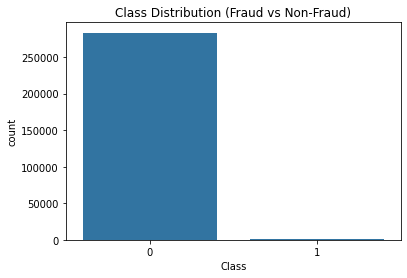

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [122]:
# CLASS DISTRIBUTION
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.show()

fraud_percentage = df["Class"].value_counts(normalize=True) * 100
print(fraud_percentage)

------------
### Step 15 – Feature Distribution Comparison (Fraud vs Non-Fraud)
-----------

Kernel Density Estimation (KDE) plots are used to compare
feature distributions between fraudulent and normal transactions.

These visualizations help identify whether certain variables
show distinct patterns for fraud.

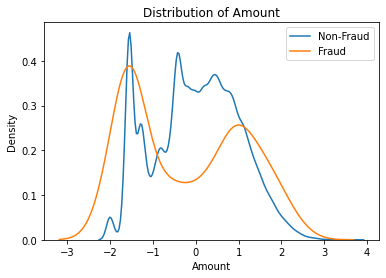

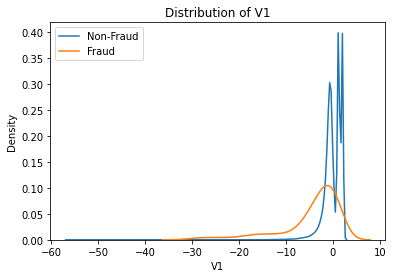

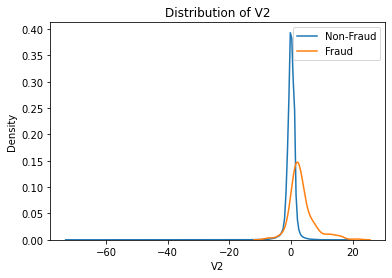

In [123]:
for col in ["Amount","V1","V2"]:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[df["Class"]==0][col], label="Non-Fraud")
    sns.kdeplot(df[df["Class"]==1][col], label="Fraud")
    plt.legend()
    plt.title(f"Distribution of {col}")
    plt.show()

---------------
### Step 16 – Feature Correlation with Fraud Target
-----------

We compute correlations between each feature and the fraud label.

Features with stronger correlation values may contain more
predictive information for detecting fraudulent transactions.

In [124]:
corr = df.corr()["Class"].sort_values(ascending=False)
print(corr.head(10))

Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64


-----------------
### Step 17 – Feature Correlation Matrix
-------------------

A correlation heatmap visualizes relationships between all features.

This analysis helps detect multicollinearity and identify
groups of strongly related variables.

Since most variables are generated using PCA,
the correlation between features is relatively low.

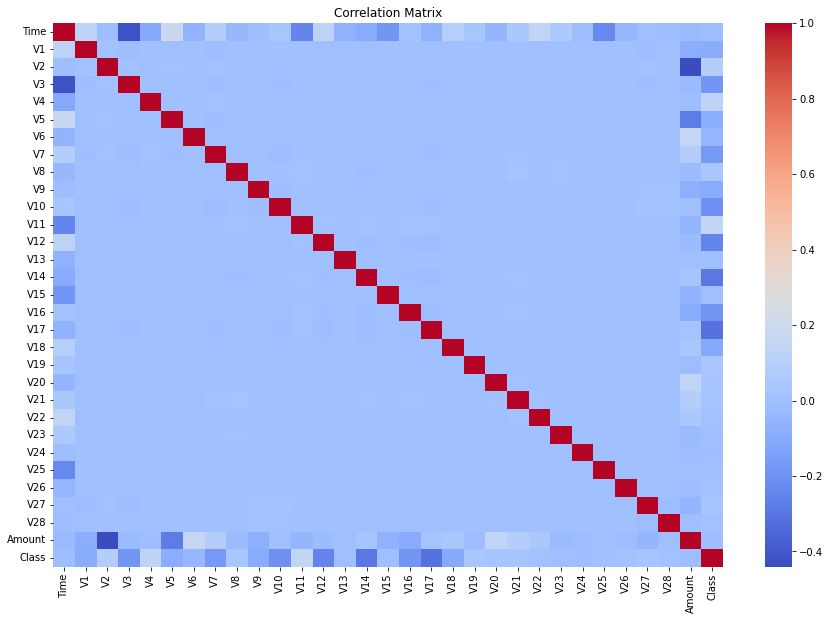

In [125]:
# CORRELATION MATRIX
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

-------------
### Step 18 – Transaction Amount vs Fraud Analysis
---------------

Boxplots compare transaction amounts for fraudulent and
non-fraudulent transactions.

This helps identify whether fraud transactions tend to occur
at specific transaction value ranges.

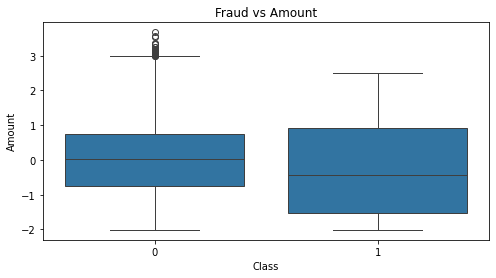

In [126]:
# FRAUD vs AMOUNT
plt.figure(figsize=(8,4))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Fraud vs Amount")
plt.show()


--------------
### Step 19 – Fraud Pattern by Hour of Day
---------------------

Fraudulent transactions may exhibit temporal patterns.

By converting transaction time into hourly intervals,
we analyze whether fraud occurs more frequently
during specific hours of the day.

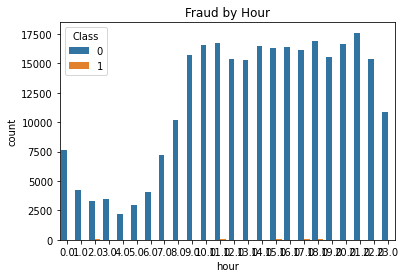

In [127]:
df["hour"] = (df["Time"] // 3600) % 24

sns.countplot(x="hour", hue="Class", data=df)
plt.title("Fraud by Hour")
plt.show()

------------------
### Step 20 – Top Features Associated with Fraud
----------------------

We rank features based on their correlation with the fraud label.

This helps identify which PCA components carry
the strongest signals related to fraudulent activity.

In [128]:
important_features = corr.abs().sort_values(ascending=False)[1:11]
print("Top 10 correlated features:\n", important_features)

Top 10 correlated features:
 V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64


------------------
### Step 21 – Pairwise Feature Interaction Visualization
-------------------
Scatter plots are used to visualize relationships between
selected feature pairs.

This helps identify whether fraudulent transactions occupy
distinct regions in the feature space.

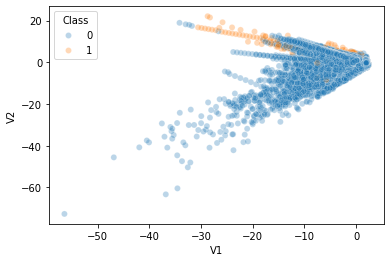

In [129]:
sns.scatterplot(x="V1", y="V2", hue="Class", data=df, alpha=0.3)
plt.show()

------------------
### Step 22 – Transaction Amount Distribution
--------------------

We visualize the overall distribution of transaction amounts.

The histogram shows that transaction values are highly skewed,
with most transactions occurring at lower amounts.

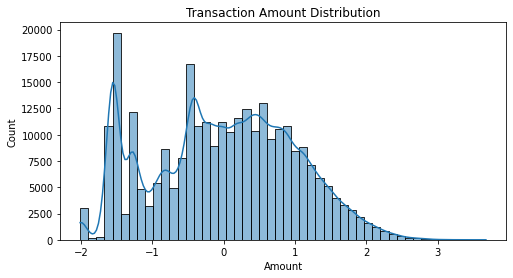

In [130]:

 plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

----------
### Step 23 – Time-Based Feature Engineering
--------------

Time features are transformed into cyclic variables
using sine and cosine transformations.

This helps machine learning models capture periodic
patterns in transaction activity.

In [131]:
df["day"] = df["Time"] // (3600*24)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["amount_to_hour_ratio"] = df["Amount"] / (df["hour"] + 1)
df = df.drop(columns=["Time", "hour"])

-----------------
### Step 24 – Feature Interaction Engineering
---------------

Interaction features are created by multiplying selected
variables.

These features help capture relationships between variables
that may signal fraudulent behavior.

In [132]:
df["V1_V2_interaction"] = df["V1"] * df["V2"]
df["V3_V4_interaction"] = df["V3"] * df["V4"]

----------
### Step 25 – High Transaction Amount Indicator
------------

A binary flag is created for unusually large transactions.

This feature marks transactions above the 95th percentile,
which may indicate higher fraud risk.

In [133]:
df["high_amount_flag"] = (df["Amount"] > df["Amount"].quantile(0.95)).astype(int)

-------------
### Step 26 – Multicollinearity Check using Variance Inflation Factor
-------------

Variance Inflation Factor (VIF) measures the degree of
multicollinearity between features.

High VIF values indicate redundant variables that may
negatively affect model stability.

In [134]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_temp = df.drop(columns=[target_col])
vif_df = pd.DataFrame()
vif_df["Feature"] = X_temp.columns
vif_df["VIF"] = [variance_inflation_factor(X_temp.values, i)
                 for i in range(X_temp.shape[1])]

print(vif_df.sort_values("VIF", ascending=False).head())

              Feature       VIF
1                  V2  3.114188
33  V1_V2_interaction  2.905205
34  V3_V4_interaction  2.461331
28             Amount  2.168047
35   high_amount_flag  2.028521


--------------------
### Step 27 – Handling Class Imbalance using SMOTE
--------------------

Fraud datasets are highly imbalanced.

SMOTE (Synthetic Minority Over-sampling Technique) generates
synthetic examples of the minority class to balance the dataset.

Balancing the dataset improves model learning
for fraudulent transactions.

In [135]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE: Class
0    226602
1    226602
Name: count, dtype: int64


------------
### Step 28 – Feature Scaling
---------------

Feature scaling standardizes the range of numerical features.

Standardization is particularly important for
distance-based algorithms such as Logistic Regression,
SVM, and KNN.

In [137]:
# only for distance based algorithms
from sklearn.preprocessing import StandardScaler

num_cols = X_train.select_dtypes(include=["float64", "int64"]).columns

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

--------------
### Key Insights from Exploratory Data Analysis
--------------

- The dataset is extremely imbalanced with very few fraud cases.
- Transaction amounts are highly skewed.
- Several PCA features show strong association with fraud.
- Fraud patterns vary across time intervals.
- Outlier transactions often contain higher fraud ratios.

These insights guide feature engineering and model development
for the fraud detection system.